~~~
Copyright 2025 Google LLC

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

    https://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.
~~~

# Fine-tune MedGemma with Hugging Face

<table><tbody><tr>
  <td style="text-align: center">
    <a href="https://colab.research.google.com/github/google-health/medgemma/blob/main/notebooks/fine_tune_with_hugging_face.ipynb">
      <img alt="Google Colab logo" src="https://www.tensorflow.org/images/colab_logo_32px.png" width="32px"><br> Run in Google Colab
    </a>
  </td>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/colab/import/https:%2F%2Fraw.githubusercontent.com%2Fgoogle-health%2Fmedgemma%2Fmain%2Fnotebooks%2Ffine_tune_with_hugging_face.ipynb">
      <img alt="Google Cloud Colab Enterprise logo" src="https://lh3.googleusercontent.com/JmcxdQi-qOpctIvWKgPtrzZdJJK-J3sWE1RsfjZNwshCFgE_9fULcNpuXYTilIR2hjwN" width="32px"><br> Run in Colab Enterprise
    </a>
  </td>
  <td style="text-align: center">
    <a href="https://github.com/google-health/medgemma/blob/main/notebooks/fine_tune_with_hugging_face.ipynb">
      <img alt="GitHub logo" src="https://github.githubassets.com/assets/GitHub-Mark-ea2971cee799.png" width="32px"><br> View on GitHub
    </a>
  </td>
  <td style="text-align: center">
    <a href="https://huggingface.co/collections/google/medgemma-release-680aade845f90bec6a3f60c4">
      <img alt="Hugging Face logo" src="https://huggingface.co/front/assets/huggingface_logo-noborder.svg" width="32px"><br> View on Hugging Face
    </a>
  </td>
</tr></tbody></table>

This notebook demonstrates fine-tuning MedGemma on an image and text dataset for a vision task using Hugging Face libraries.

In this guide, you will use Hugging Face's [Transformer Reinforcement Learning (`TRL`)](https://github.com/huggingface/trl) library to train the model with Supervised Fine-Tuning (SFT), utilizing [Quantized Low-Rank Adaptation (QLoRA)](https://arxiv.org/abs/2305.14314) to reduce computational costs while maintaining high performance.


## Setup

To complete this tutorial, you'll need to have a runtime with sufficient resources to fine-tune the MedGemma model. **Note:** This guide requires a GPU that supports bfloat16 data type and has at least 40 GB of memory.

You can run this notebook in Google Colab using an A100 GPU:

1. In the upper-right of the Colab window, select **▾ (Additional connection options)**.
2. Select **Change runtime type**.
3. Under **Hardware accelerator**, select **A100 GPU**.

### Get access to MedGemma

Before you get started, make sure that you have access to MedGemma models on Hugging Face:

1. If you don't already have a Hugging Face account, you can create one for free by clicking [here](https://huggingface.co/join).
2. Head over to the [MedGemma model page](https://huggingface.co/google/medgemma-4b-it) and accept the usage conditions.

### Configure your HF token

Generate a Hugging Face `write` access token by going to [settings](https://huggingface.co/settings/tokens). **Note:** Make sure that the token has write access to push the fine-tuned model to Hugging Face Hub.

If you are using Google Colab, add your access token to the Colab Secrets manager to securely store it. If not, proceed to run the cell below to authenticate with Hugging Face.

1. Open your Google Colab notebook and click on the 🔑 Secrets tab in the left panel. <img src="https://storage.googleapis.com/generativeai-downloads/images/secrets.jpg" alt="The Secrets tab is found on the left panel." width=50%>
2. Create a new secret with the name `HF_TOKEN`.
3. Copy/paste your token key into the Value input box of `HF_TOKEN`.
4. Toggle the button on the left to allow notebook access to the secret.

In [1]:
import os
import sys

if "google.colab" in sys.modules and not os.environ.get("VERTEX_PRODUCT"):
    # Use secret if running in Google Colab
    from google.colab import userdata
    os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
else:
    # Store Hugging Face data under `/content` if running in Colab Enterprise
    if os.environ.get("VERTEX_PRODUCT") == "COLAB_ENTERPRISE":
        os.environ["HF_HOME"] = "/content/hf"
    # Authenticate with Hugging Face
    from huggingface_hub import get_token
    if get_token() is None:
        from huggingface_hub import notebook_login
        notebook_login()

### Install dependencies

In [2]:
! pip install --upgrade --quiet bitsandbytes datasets evaluate peft tensorboard transformers trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 190.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 177.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 678.0/678.0 kB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 68.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires tensorboard~=2.19.0, but you have tensorboard 2.20.0 which is incompatible.


## Prepare fine-tuning dataset

This notebook uses the [Chest X-ray Images](https://huggingface.co/datasets/hf-vision/chest-xray-pneumonia) dataset which contains chest X-ray images labeled as NORMAL or PNEUMONIA, to fine-tune MedGemma to determine the presence of pneumonia.

**Note:** The dataset is organized into train/test/val folders. By default this guide uses the training split. You can adjust the paths as needed.

**Dataset citation:** Kermany, Daniel; Zhang, Kang; Goldbaum, Michael (2018), “Labeled Optical Coherence Tomography (OCT) and Chest X-Ray Images for Classification”, Mendeley Data, V2, doi: 10.17632/rscbjbr9sj.2

Download the dataset. This step may take around 15 minutes to complete.

In [3]:
# ! wget -nc -q "https://zenodo.org/records/1214456/files/NCT-CRC-HE-100K.zip"
# ! unzip -q NCT-CRC-HE-100K.zip

Load the data using the Hugging Face `datasets` library. Then, create train and validation splits.

In [4]:
from datasets import load_dataset

train_size = 4000  # @param {type: "number"}
validation_size = 16  # @param {type: "number"}

data = load_dataset("hf-vision/chest-xray-pneumonia")

# Subsample train for speed; use full validation split (only 16 samples)
data["train"] = data["train"].shuffle(seed=42).select(range(min(train_size, len(data["train"]))))
data["validation"] = data["validation"]

# Display dataset details
data

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00007.parquet:   0%|          | 0.00/446M [00:00<?, ?B/s]

data/train-00001-of-00007.parquet:   0%|          | 0.00/385M [00:00<?, ?B/s]

data/train-00002-of-00007.parquet:   0%|          | 0.00/68.9M [00:00<?, ?B/s]

data/train-00003-of-00007.parquet:   0%|          | 0.00/74.1M [00:00<?, ?B/s]

...

data/test-00000-of-00001.parquet:   0%|          | 0.00/78.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5216 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/16 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/624 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 4000
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 16
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 624
    })
})

Inspect a sample data point, which contains:

* `image`: chest X-ray image as a `PIL` image object
* `label`: integer class label — 0 for NORMAL, 1 for PNEUMONIA

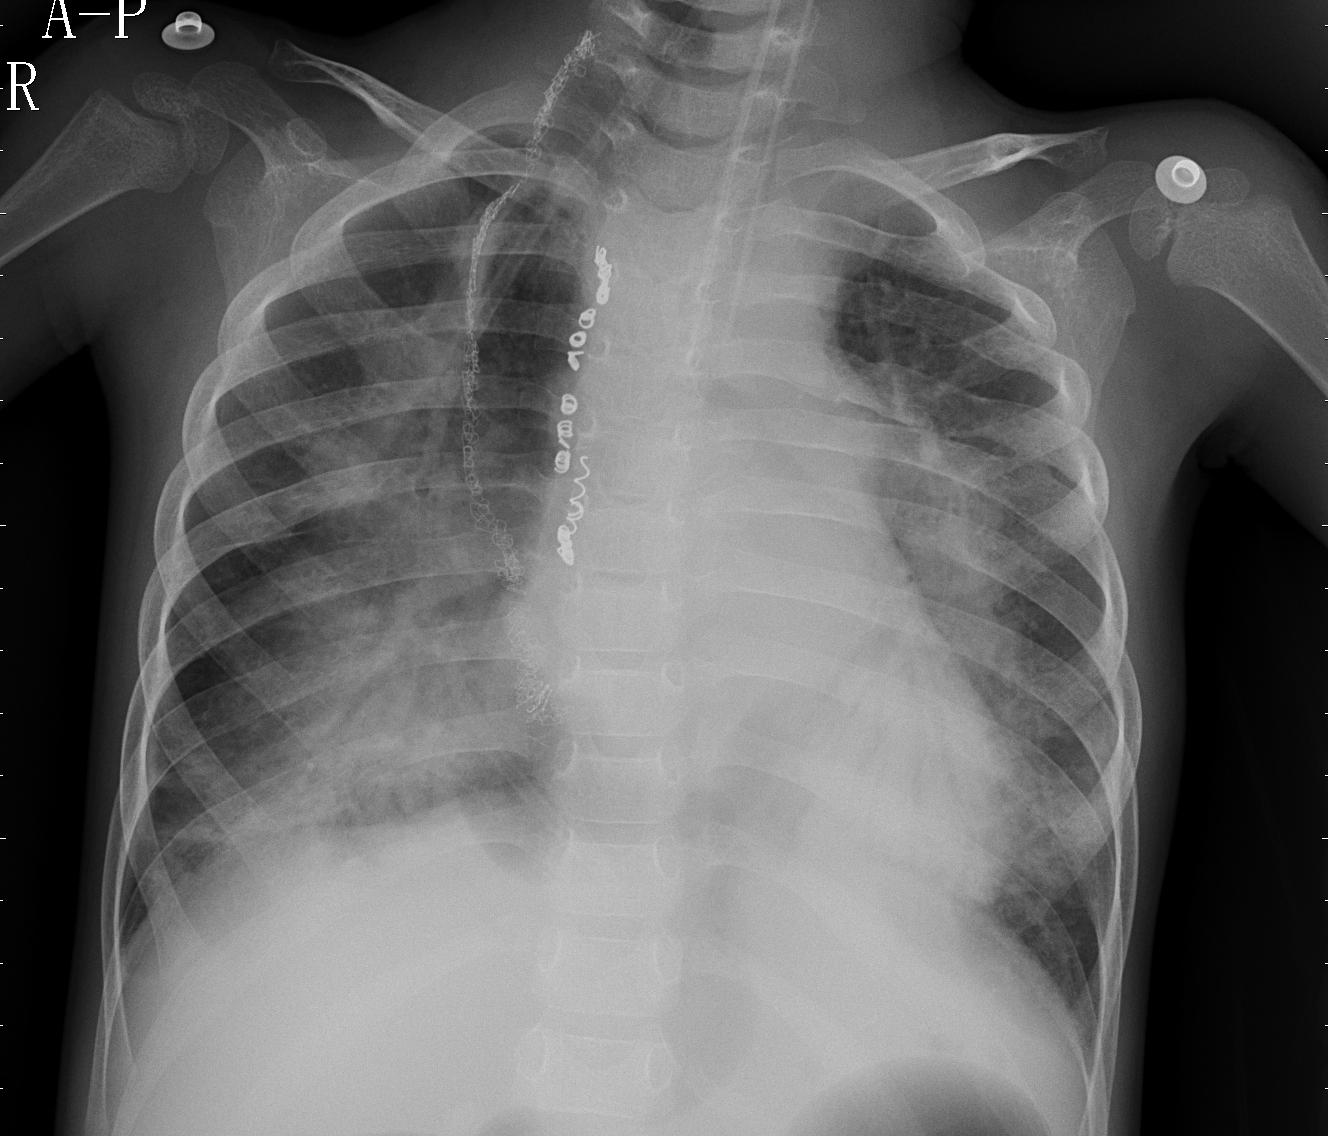

In [5]:
data["train"][0]["image"]

In [6]:
data["train"][0]["label"]

1

For this classification task, create a multiple-choice question prompt and preprocess the data into a multimodal conversational format.

In [3]:
from typing import Any

PNEUMONIA_CLASSES = [
    "A: No — the image does not show pneumonia",
    "B: Yes — the image shows pneumonia",
]

options = "\n".join(PNEUMONIA_CLASSES)
PROMPT = f"Does this chest X-ray show signs of pneumonia? Answer Yes or No.\n{options}"


def format_data(example: dict[str, Any]) -> dict[str, Any]:
    example["messages"] = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                },
                {
                    "type": "text",
                    "text": PROMPT,
                },
            ],
        },
        {
            "role": "assistant",
            "content": [
                {
                    "type": "text",
                    "text": PNEUMONIA_CLASSES[example["label"]],
                },
            ],
        },
    ]
    return example

Apply the processing function on the dataset.

In [8]:
data = data.map(format_data)

# Display a processed data sample
data["train"][0]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/16 [00:00<?, ? examples/s]

Map:   0%|          | 0/624 [00:00<?, ? examples/s]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=L size=1328x1136>,
 'label': 1,
 'messages': [{'content': [{'text': None, 'type': 'image'},
    {'text': 'Does this chest X-ray show signs of pneumonia? Answer Yes or No.\nA: No — the image does not show pneumonia\nB: Yes — the image shows pneumonia',
     'type': 'text'}],
   'role': 'user'},
  {'content': [{'text': 'B: Yes — the image shows pneumonia', 'type': 'text'}],
   'role': 'assistant'}]}

## Fine-tune the model with LoRA

Traditional fine-tuning of large language models is resource-intensive because it requires adjusting billions of parameters. Parameter-Efficient Fine-Tuning (PEFT) addresses this by training a smaller number of parameters. A common PEFT technique is Low-Rank Adaptation (LoRA), which efficiently adapts large language models by training small, low-rank matrices that are added to the original model instead of updating the full-weight matrices. In QLoRA, the base model is quantized to 4-bit before its weights are frozen, then LoRA adapter layers are attached and trained.

This notebook demonstrates supervised fine-tuning MedGemma with QLoRA using the `SFTTrainer` from the Hugging Face `TRL` library.

### Load model from Hugging Face Hub

Initialize the quantization configuration and load the model.

In [33]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig

model_id = "google/medgemma-4b-it"

# Check if GPU supports bfloat16
if torch.cuda.get_device_capability()[0] < 8:
    raise ValueError("GPU does not support bfloat16, please use a GPU that supports bfloat16.")

model_kwargs = dict(
    attn_implementation="eager",
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

model_kwargs["quantization_config"] = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=model_kwargs["torch_dtype"],
    bnb_4bit_quant_storage=model_kwargs["torch_dtype"],
)

model = AutoModelForImageTextToText.from_pretrained(model_id, **model_kwargs)
processor = AutoProcessor.from_pretrained(model_id)

# Use right padding to avoid issues during training
processor.tokenizer.padding_side = "right"

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

### Set up for fine-tuning

Create a [`LoraConfig`](https://huggingface.co/docs/peft/package_reference/lora#peft.LoraConfig). It will be provided to the `SFTTrainer`, which supports built-in integration with the Hugging Face `PEFT` library.

In [10]:
from peft import LoraConfig

peft_config = LoraConfig(
    lora_alpha=16,
    lora_dropout=0.05,
    r=16,
    bias="none",
    target_modules="all-linear",
    task_type="CAUSAL_LM",
    modules_to_save=[
        "lm_head",
        "embed_tokens",
    ],
)

Define a custom data collator that processes examples containing text and images and returns batches of data in the expected model input format.

In [11]:
from typing import Any


def collate_fn(examples: list[dict[str, Any]]):
    texts = []
    images = []
    for example in examples:
        images.append([example["image"].convert("RGB")])
        texts.append(processor.apply_chat_template(
            example["messages"], add_generation_prompt=False, tokenize=False
        ).strip())

    # Tokenize the texts and process the images
    batch = processor(text=texts, images=images, return_tensors="pt", padding=True)

    # The labels are the input_ids, with the padding and image tokens masked in
    # the loss computation
    labels = batch["input_ids"].clone()

    # Mask image tokens
    image_token_id = [
        processor.tokenizer.convert_tokens_to_ids(
            processor.tokenizer.special_tokens_map["boi_token"]
        )
    ]
    # Mask tokens that are not used in the loss computation
    labels[labels == processor.tokenizer.pad_token_id] = -100
    labels[labels == image_token_id] = -100
    labels[labels == 262144] = -100

    batch["labels"] = labels
    return batch

Configure training parameters in an [`SFTConfig`](https://huggingface.co/docs/trl/sft_trainer#trl.SFTConfig).

In [12]:
from trl import SFTConfig

num_train_epochs = 8  # @param {type: "number"}
learning_rate = 2e-4  # @param {type: "number"}

args = SFTConfig(
    output_dir="medgemma-4b-it-sft-lora-crc100k",            # Directory and Hub repository id to save the model to
    num_train_epochs=num_train_epochs,                       # Number of training epochs
    per_device_train_batch_size=4,                           # Batch size per device during training
    per_device_eval_batch_size=4,                            # Batch size per device during evaluation
    gradient_accumulation_steps=4,                           # Number of steps before performing a backward/update pass
    gradient_checkpointing=True,                             # Enable gradient checkpointing to reduce memory usage
    optim="adamw_torch_fused",                               # Use fused AdamW optimizer for better performance
    logging_steps=50,                                        # Number of steps between logs
    save_strategy="epoch",                                   # Save checkpoint every epoch
    eval_strategy="steps",                                   # Evaluate every `eval_steps`
    eval_steps=50,                                           # Number of steps between evaluations
    learning_rate=learning_rate,                             # Learning rate based on QLoRA paper
    bf16=True,                                               # Use bfloat16 precision
    max_grad_norm=0.3,                                       # Max gradient norm based on QLoRA paper
    warmup_ratio=0.03,                                       # Warmup ratio based on QLoRA paper
    lr_scheduler_type="linear",                              # Use linear learning rate scheduler
    push_to_hub=True,                                        # Push model to Hub
    report_to="tensorboard",                                 # Report metrics to tensorboard
    gradient_checkpointing_kwargs={"use_reentrant": False},  # Set gradient checkpointing to non-reentrant to avoid issues
    dataset_kwargs={"skip_prepare_dataset": True},           # Skip default dataset preparation to preprocess manually
    remove_unused_columns = False,                           # Columns are unused for training but needed for data collator
    label_names=["labels"],                                  # Input keys that correspond to the labels
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


### Fine-tune the model

Construct an [`SFTTrainer`](https://huggingface.co/docs/trl/sft_trainer) using the previously defined LoRA configuration, custom data collator, and training parameters.

In [13]:
from trl import SFTTrainer

trainer = SFTTrainer(
    model=model,
    args=args,
    train_dataset=data["train"],
    eval_dataset=data["validation"],
    peft_config=peft_config,
    processing_class=processor,
    data_collator=collate_fn,
)

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:1348: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


Launch the fine-tuning process.

**Note**: This may take around 3 hours to run using the default configuration.

In [14]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2, 'pad_token_id': 0}.


Step,Training Loss,Validation Loss
50,1.944532,0.043646
100,0.029824,0.024599
150,0.026531,0.034127
200,0.025529,0.031671
250,0.024862,0.024202
300,0.024813,0.024043
350,0.025065,0.024062
400,0.025105,0.026850
450,0.024409,0.024212
500,0.024709,0.026125


TrainOutput(global_step=2000, training_loss=0.07253352850675583, metrics={'train_runtime': 31893.0024, 'train_samples_per_second': 1.003, 'train_steps_per_second': 0.063, 'total_flos': 2.624375399712169e+17, 'train_loss': 0.07253352850675583})

Save the final model to Hugging Face Hub.

In [31]:
trainer.save_model()

NameError: name 'trainer' is not defined

Free up memory before proceeding to evaluate and test the fine-tuned model.

In [29]:
del model
del trainer
torch.cuda.empty_cache()

NameError: name 'model' is not defined

## Load trained model From Hugging Face

Install dependencies

In [4]:
!pip install --upgrade --quiet bitsandbytes transformers peft accelerate
!pip install --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 41.9 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


Authenticate

In [5]:
from huggingface_hub import notebook_login
notebook_login()

Load the fine-tuned model directly from the Hugging Face

In [27]:
import gc
import torch

# Clear any leftover models
try:
    del model
    del base_model
    del ft_pipe
except:
    pass

gc.collect()
torch.cuda.empty_cache()

# Confirm free memory
print(f"Free GPU memory: {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB")

Free GPU memory: 101.3 GB


In [28]:
import torch
from transformers import AutoModelForImageTextToText, AutoProcessor, BitsAndBytesConfig, pipeline, GenerationConfig
from peft import PeftModel

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_storage=torch.bfloat16
)

processor = AutoProcessor.from_pretrained("google/medgemma-4b-it")
processor.tokenizer.padding_side = "left"

base_model = AutoModelForImageTextToText.from_pretrained(
    "google/medgemma-4b-it",
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
model = PeftModel.from_pretrained(base_model, "yhussain/medgemma-4b-it-sft-lora-crc100k")

# Verify quantization applied
print(base_model.hf_quantizer)
free = torch.cuda.mem_get_info()[0] / 1024**3
print(f"Free GPU memory after loading base: {free:.1f} GB")

# ft_pipe = pipeline(
#     "image-text-to-text",
#     model=model,
#     processor=processor,
#     torch_dtype=torch.bfloat16,
# )
# ft_pipe.model.generation_config = GenerationConfig(
#     do_sample=False,
#     pad_token_id=processor.tokenizer.eos_token_id,
# )

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:1348: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


Free GPU memory after loading base: 86.0 GB


## Evaluate the fine-tuned model

### Prepare test dataset

Use the built-in test split of the chest X-ray dataset for evaluation.

**Note:** By default the dataset contains ~600 samples for testing.

Download and prepare the test dataset.

In [17]:
# ! wget -nc -q "https://zenodo.org/records/1214456/files/CRC-VAL-HE-7K.zip"
# ! unzip -q CRC-VAL-HE-7K.zip

In [29]:
from typing import Any

from datasets import load_dataset


def format_test_data(example: dict[str, Any]) -> dict[str, Any]:
    example["messages"] = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                },
                {
                    "type": "text",
                    "text": PROMPT,
                },
            ],
        },
    ]
    return example


# Use the test split (624 samples)
test_data = load_dataset("hf-vision/chest-xray-pneumonia", split="test")
test_data = test_data.shuffle(seed=42).select(range(min(500, len(test_data))))
test_data = test_data.map(format_test_data)

### Set up for evaluation

Load the accuracy and F1 score metrics to evaluate the model's performance on the classfication task.

In [30]:
import evaluate

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

# Ground-truth labels
REFERENCES = test_data["label"]


def compute_metrics(predictions: list[int]) -> dict[str, float]:
    metrics = {}
    metrics.update(accuracy_metric.compute(
        predictions=predictions,
        references=REFERENCES,
    ))
    metrics.update(f1_metric.compute(
        predictions=predictions,
        references=REFERENCES,
        average="binary",
    ))
    return metrics

Define a postprocessing function to convert responses to integer class labels before computing metrics.

In [34]:
from datasets import ClassLabel

# Cast label column to named ClassLabel using pneumonia classes
test_data = test_data.cast_column(
    "label",
    ClassLabel(names=PNEUMONIA_CLASSES)
)

LABEL_FEATURE = test_data.features["label"]
# Mapping to alternative label format, e.g. `(A) No`
ALT_LABELS = dict([
    (label, f"({label.replace(': ', ') ')}") for label in PNEUMONIA_CLASSES
])


def postprocess(prediction, do_full_match: bool = False) -> int:
    # Handle both dict and list-of-dict output formats
    if isinstance(prediction, dict):
        response_text = prediction["generated_text"]
    else:
        response_text = prediction[0]["generated_text"]

    response_text = response_text.strip()

    if do_full_match:
        return LABEL_FEATURE.str2int(response_text)
    for label in PNEUMONIA_CLASSES:
        if label in response_text or ALT_LABELS[label] in response_text:
            return LABEL_FEATURE.str2int(label)
    if "Yes" in response_text or "yes" in response_text:
        return LABEL_FEATURE.str2int(PNEUMONIA_CLASSES[1])
    if "No" in response_text or "no" in response_text:
        return LABEL_FEATURE.str2int(PNEUMONIA_CLASSES[0])
    return -1

Casting the dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

### Compute baseline metrics on the pretrained model

Load the pretrained model using the `pipeline` API.

In [15]:
from transformers import pipeline

pt_pipe = pipeline(
    "image-text-to-text",
    model="google/medgemma-4b-it",
    torch_dtype=torch.bfloat16,
)

from transformers import GenerationConfig
pt_pipe.model.generation_config = GenerationConfig(
    do_sample=False,
    pad_token_id=processor.tokenizer.eos_token_id,
)

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

Run batch inference on the test dataset.

In [16]:
texts = [
    pt_pipe.processor.apply_chat_template(
        msgs, add_generation_prompt=True, tokenize=False
    )
    for msgs in test_data["messages"]
]

pt_outputs = pt_pipe(
    text=texts,
    images=[[img.convert("RGB")] for img in test_data["image"]],
    max_new_tokens=40,
    batch_size=8,
    return_full_text=False,
)
pt_predictions = [postprocess(out) for out in pt_outputs]

The input data was not formatted as a chat with dicts containing 'role' and 'content' keys, even though this model supports chat. Consider using the chat format for better results. For more information, see https://huggingface.co/docs/transformers/en/chat_templating
Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=40) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Compute metrics.

In [17]:
pt_metrics = compute_metrics(pt_predictions)
print(f"Baseline metrics: {pt_metrics}")

Baseline metrics: {'accuracy': 0.388, 'f1': 0.019230769230769232}


### Compute metrics on the fine-tuned model

Load the base model with the fine-tuned LoRA adapter using the `pipeline` API.

In [35]:
ft_pipe = pipeline(
    "image-text-to-text",
    model=model,
    processor=processor,
    torch_dtype=torch.bfloat16,
)

# Set `do_sample = False` for deterministic responses
ft_pipe.model.generation_config.do_sample = False
ft_pipe.model.generation_config.pad_token_id = processor.tokenizer.eos_token_id
# Use left padding during inference
processor.tokenizer.padding_side = "left"

The model 'PeftModelForCausalLM' is not supported for image-text-to-text. Supported models are ['AriaForConditionalGeneration', 'AyaVisionForConditionalGeneration', 'BlipForConditionalGeneration', 'Blip2ForConditionalGeneration', 'ChameleonForConditionalGeneration', 'Cohere2VisionForConditionalGeneration', 'DeepseekVLForConditionalGeneration', 'DeepseekVLHybridForConditionalGeneration', 'Emu3ForConditionalGeneration', 'Ernie4_5_VLMoeForConditionalGeneration', 'EvollaForProteinText2Text', 'FastVlmForConditionalGeneration', 'Florence2ForConditionalGeneration', 'FuyuForCausalLM', 'Gemma3ForConditionalGeneration', 'Gemma3nForConditionalGeneration', 'Gemma4ForConditionalGeneration', 'GitForCausalLM', 'Glm46VForConditionalGeneration', 'Glm4vForConditionalGeneration', 'Glm4vMoeForConditionalGeneration', 'GlmOcrForConditionalGeneration', 'GotOcr2ForConditionalGeneration', 'IdeficsForVisionText2Text', 'Idefics2ForConditionalGeneration', 'Idefics3ForConditionalGeneration', 'InstructBlipForCondit

Run batch inference on the test dataset.

In [36]:
texts = [
    ft_pipe.processor.apply_chat_template(
        msgs, add_generation_prompt=True, tokenize=False
    )
    for msgs in test_data["messages"]
]

# ft_outputs = ft_pipe(
#     text=texts,
#     images=[[img.convert("RGB")] for img in test_data["image"]],
#     max_new_tokens=20,
#     batch_size=2,
#     return_full_text=False,
# )

# Remove the conflicting max_length
ft_pipe.model.generation_config.max_length = None

# Process one at a time
import gc

ft_outputs = []
for i, (text, image) in enumerate(zip(texts, test_data["image"])):
    output = ft_pipe(
        text=text,
        images=[image.convert("RGB")],
        max_new_tokens=20,
        return_full_text=False,
    )
    ft_outputs.append(output)

    if i % 50 == 0:
        gc.collect()
        torch.cuda.empty_cache()
        print(f"Processed {i}/{len(texts)}")

ft_predictions = [postprocess(out, do_full_match=True) for out in ft_outputs]

Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Processed 0/500


Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

Processed 50/500


Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

...

Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

Processed 400/500


Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

Processed 450/500


Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

Compute metrics.

In [37]:
ft_metrics = compute_metrics(ft_predictions)
print(f"Fine-tuned metrics: {ft_metrics}")

Fine-tuned metrics: {'accuracy': 0.776, 'f1': 0.8465753424657534}


# Next steps

Explore the other [notebooks](https://github.com/google-health/medgemma/blob/main/notebooks) to learn what else you can do with the model.